In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\victo\miniconda3\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "C:\Users\victo\miniconda3\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_

Failed to read module file 'C:\Users\victo\miniconda3\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "C:\Users\victo\miniconda3\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324,

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)

from src.utils import configure_logger

import pandas as pd

from typing import Any
from qqe.src.GNN.training.utils import collect_dataset_paths
from qqe.src.GNN.training.runners import MODEL_REGISTRY
from qqe.src.GNN.training.train_config import TrainConfig

from collections.abc import Callable
Loader = Callable[..., Any]

In [3]:
import numpy as np

from qqe.src.experiments.plotting import _plot_SRE_distribution
from qqe.src.GNN.dataset_builder import (
    DataGenConfig,
    RegimeDistribution,
    SamplingConfig,
    run_dataset_pipeline,
)
PROJECT_ROOT = Path().resolve().parent

In [4]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

### Create test datasets

In [18]:
def default_sampling_config() -> SamplingConfig:
    return SamplingConfig(
        clifford=RegimeDistribution(
            regimes=["zero", "low", "medium", "high"],
            probabilities=[0.10, 0.20, 0.20, 0.50],
        ),
        random=RegimeDistribution(
            regimes=["identity_like", "clifford_like", "small_angles", "generic"],
            probabilities=[0.10, 0.20, 0.20, 0.50],
        ),
        quansistor=RegimeDistribution(
            regimes=[
                "identity_like",
                "weak",
                "moderate",
                "structured_equal_ab",
                "structured_opposite_ab",
                "generic_uniform",
            ],
            probabilities=[0.2, 0.15, 0.15, 0.15, 0.15, 0.2],
        ),
        haar=RegimeDistribution(
            regimes=["none", "sparse_weak", "dense_weak", "sparse_full", "medium", "full"],
            probabilities=[0.10, 0.15, 0.15, 0.15, 0.15, 0.30],
        ),
    )


def test_dataset_builder(
    backend: str = "pennylane",
    target: str = "SRE",
    method: str = "fwht",
    use_dask: bool = True,
    output_dir: str = "outputs/data/test_dataset_2",
    n_bins_option: int = 50,
    families: str ="quansistor",
    n_seeds_option: int = 50,
    prediction_n_seeds_option: int | None = 5,
    qubits_min: int = 4,
    qubits_max: int = 10,
    qubits_step: int = 2,
    layers_min: int = 2,
    layers_max: int = 100,
    layers_step: int = 2,
    target_qubits: str = "4,6,8",
    max_configs: int | None = None,
    dask_n_workers: int = 4,
    dask_memory_per_worker: str = "32GiB",
):
    selected_families = [f.strip() for f in families.split(",") if f.strip()]

    qubits_values = np.arange(qubits_min, qubits_max + 1, qubits_step)
    layers_values = np.concatenate(
        ([1], np.arange(layers_min, layers_max + 1, layers_step)),
    )

    selected_target_qubits = tuple(
        int(q.strip()) for q in target_qubits.split(",") if q.strip()
    )

    target_norm = target.strip().lower()

    compute_sre = target_norm == "sre"
    compute_EE = target_norm == "ee"

    if target_norm not in {"sre", "ee", "none"}:
        raise ValueError("target must be 'SRE', 'EE', or 'none'")

    output_path = PROJECT_ROOT / output_dir.strip("/")

    logger.info(f"Building datasets in {output_path}...")
    config = DataGenConfig(
        backend=backend,
        method=method,
        families=selected_families,
        qubits_values=qubits_values,
        layers_values=layers_values,
        n_seeds=n_seeds_option,
        prediction_n_seeds=prediction_n_seeds_option,
        n_bins=n_bins_option,
        compute_sre=compute_sre,
        compute_EE=compute_EE,
        target_qubits=selected_target_qubits,
        representation="dense",
        use_dask=use_dask,
        dask_n_workers=dask_n_workers,
        dask_memory_per_worker=dask_memory_per_worker,
        output_dir=output_path,
        max_configs=max_configs,
    )

    run_dataset_pipeline(
        config=config,
        families=selected_families,
        qubits_values=qubits_values,
        layers_values=layers_values,
        n_seeds=n_seeds_option,
        use_dask=use_dask,
        max_configs=max_configs,
        dask_n_workers=dask_n_workers,
        dask_memory_per_worker=dask_memory_per_worker,
        sampling_config=default_sampling_config(),
    )

In [19]:
test_dataset_builder()

2026-05-20 15:34:34,365 - __main__ - INFO - Building datasets in C:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\qqe\outputs\data\test_dataset_2...
2026-05-20 15:34:34,367 - qqe.src.GNN.dataset_builder - INFO - Processing family: quansistor
2026-05-20 15:34:34,411 - qqe.src.GNN.dataset_builder - INFO - Generated 10200 configs for quansistor
2026-05-20 15:34:34,414 - qqe.src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-20 15:34:34,473 - distributed.scheduler - INFO - State start
2026-05-20 15:34:34,502 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:52600
2026-05-20 15:34:34,504 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-05-20 15:34:34,506 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-20 15:34:34,534 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 15.64 GiB
2026-05-20 15:

### Visualize distributions

In [7]:
def make_dataset_loaders(
    model_type: str,
    epochs: int,
    lr: float,
    loss_type: str,
    batch_size: int,
    training_mode: str,
    family: str,
    target: str,
    data_dir: str,
    model_save_path: str,
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 10,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 600.0,
):
    cfg = TrainConfig(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        show_progress=show_progress,
        show_val_progress=show_val_progress,
        log_batch_loss_every=log_every_n_batches,
        heartbeat=heartbeat_secs,
        epoch_warning=epoch_time_warning_secs,
    )

    train_paths = collect_dataset_paths(
        data_dir,
        family=family if training_mode == "per_family" else None,
        split="target",
    )
    if not train_paths:
        raise RuntimeError("No data paths found.")
    logger.info(f"Found {len(train_paths)} data paths.")
    logger.info("Data paths collected.")

    spec = MODEL_REGISTRY[model_type]
    logger.info(f"Building loaders and model for model_type={model_type}...")

    loader_fn: Loader = spec["build_loaders"]
    returns_nodes_dim: bool = spec.get("returns_nodes_dim", False)
    if returns_nodes_dim:
        train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family,
        )
    else:
        train_loader, val_loader, test_loader, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family,
        )
        node_in_dim = global_in_dim

    return train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset

In [ ]:
model_type="gnn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
# data_dir = "../outputs/data/dataset"
model_save_path = "../outputs/models/clifford_model_gnn.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0

In [ ]:
data_dir = "../outputs/data/test_dataset_2"
# train_loader_haar, val_loader_haar, test_loader_haar, node_in_dim_haar, global_in_dim_haar, base_dataset_haar = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "haar", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)
train_loader_quansistor, val_loader_quansistor, test_loader_quansistor, node_in_dim_quansistor, global_in_dim_quansistor, base_dataset_quansistor = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "quansistor", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)

2026-05-20 15:07:32,803 - __main__ - INFO - Found 7650 data paths.
2026-05-20 15:07:32,805 - __main__ - INFO - Data paths collected.
2026-05-20 15:07:32,805 - __main__ - INFO - Building loaders and model for model_type=gnn...


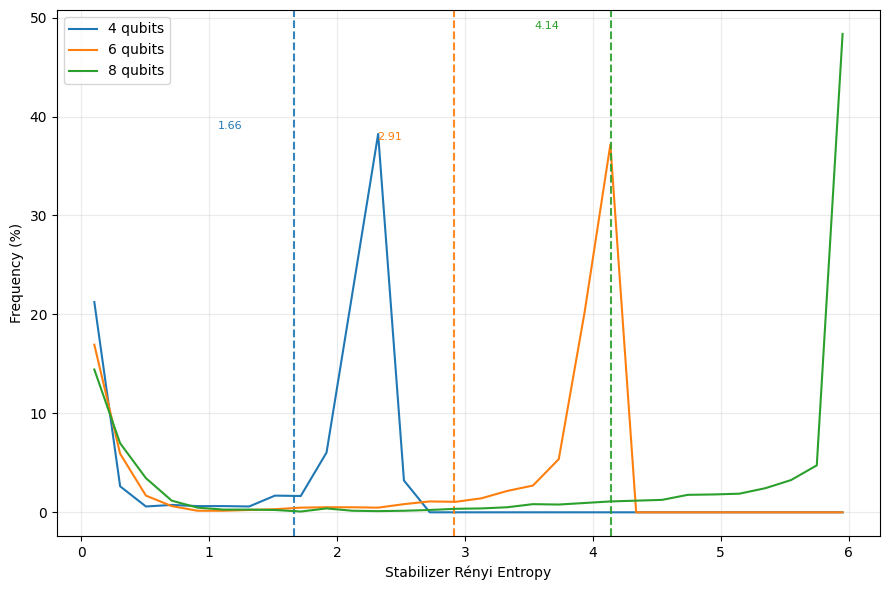

In [13]:
# _plot_SRE_distribution(base_dataset_haar, value_range=(-0.5, 9))
_plot_SRE_distribution(base_dataset_quansistor)

2026-05-20 15:30:59,017 - __main__ - INFO - Found 7650 data paths.
2026-05-20 15:30:59,019 - __main__ - INFO - Data paths collected.
2026-05-20 15:30:59,020 - __main__ - INFO - Building loaders and model for model_type=gnn...


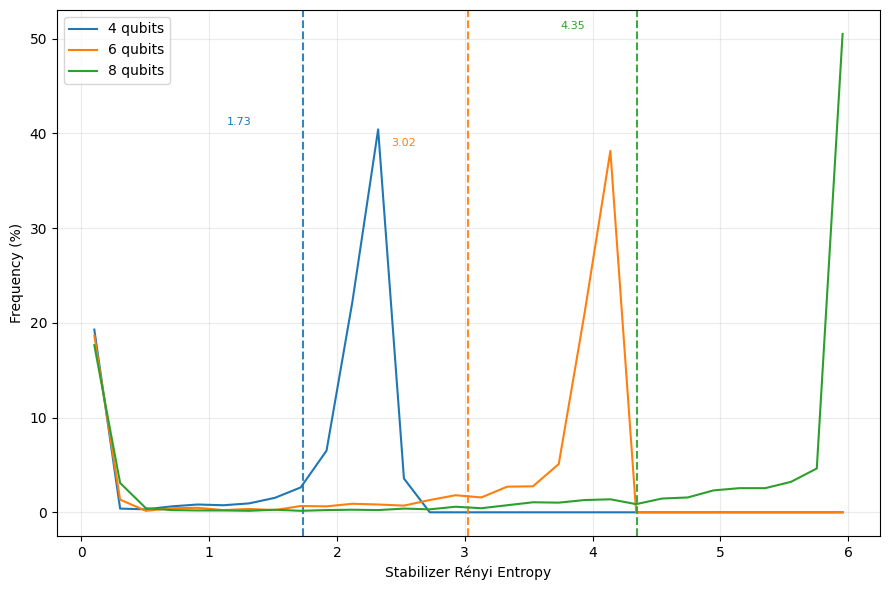

In [17]:
data_dir = "../outputs/data/test_dataset_2"
# train_loader_haar, val_loader_haar, test_loader_haar, node_in_dim_haar, global_in_dim_haar, base_dataset_haar = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "haar", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)
train_loader_quansistor, val_loader_quansistor, test_loader_quansistor, node_in_dim_quansistor, global_in_dim_quansistor, base_dataset_quansistor = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "quansistor", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)
# _plot_SRE_distribution(base_dataset_haar, value_range=(-0.5, 9))
_plot_SRE_distribution(base_dataset_quansistor)

2026-05-20 16:50:23,774 - __main__ - INFO - Found 7650 data paths.
2026-05-20 16:50:23,776 - __main__ - INFO - Data paths collected.
2026-05-20 16:50:23,777 - __main__ - INFO - Building loaders and model for model_type=gnn...


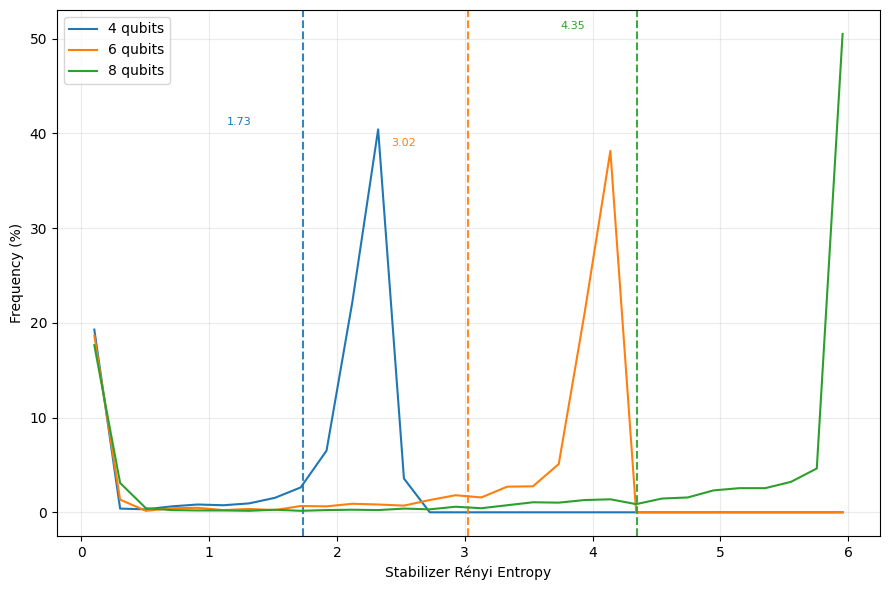

In [20]:
data_dir = "../outputs/data/test_dataset_2"
# train_loader_haar, val_loader_haar, test_loader_haar, node_in_dim_haar, global_in_dim_haar, base_dataset_haar = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "haar", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)
train_loader_quansistor, val_loader_quansistor, test_loader_quansistor, node_in_dim_quansistor, global_in_dim_quansistor, base_dataset_quansistor = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "quansistor", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)
# _plot_SRE_distribution(base_dataset_haar, value_range=(-0.5, 9))
_plot_SRE_distribution(base_dataset_quansistor)